<a href="https://colab.research.google.com/github/ksantos-helo/Challenge---TelecomX_BR/blob/main/Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introdução ao Projeto

Este projeto tem como objetivo analisar os fatores que influenciam a evasão de clientes (Churn) em uma empresa de telecomunicações.

A análise busca identificar padrões e variáveis que contribuem para o cancelamento do serviço.


# 1. Importação das bibliotecas


In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Ingestão de Dados – Coleta via API

Nesta etapa realizamos a conexão com a API da Telecom X, extraímos os dados no formato JSON e os convertemos para um DataFrame do Pandas para permitir a manipulação e análise dos dados.

In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

try:

    response = requests.get(url, timeout=10)

    response.raise_for_status()

    data = response.json()

    df = pd.json_normalize(data)

    print("Dados carregados com sucesso!")
    print("Linhas e colunas:", df.shape)

except requests.exceptions.RequestException as e:

    print("Erro ao acessar API:", e)


Dados carregados com sucesso!
Linhas e colunas: (7267, 21)


#3. Exploração inicial do dataset
   - 3.1 Visualização das colunas

   - 3.2 Verificação dos tipos de dados

   - 3.3 Análise das variáveis categóricas

   - 3.4 Dicionário de dados

## 3.1 Visualização das Colunas

Objetivo: entender estrutura geral do dataset.

In [3]:
df.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
df.shape


(7267, 21)

In [5]:
df.columns



Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [6]:
for coluna in df.columns:
    print(coluna)


customerID
Churn
customer.gender
customer.SeniorCitizen
customer.Partner
customer.Dependents
customer.tenure
phone.PhoneService
phone.MultipleLines
internet.InternetService
internet.OnlineSecurity
internet.OnlineBackup
internet.DeviceProtection
internet.TechSupport
internet.StreamingTV
internet.StreamingMovies
account.Contract
account.PaperlessBilling
account.PaymentMethod
account.Charges.Monthly
account.Charges.Total


## 3.2 Verificação dos Tipos de Dados

Objetivo:

- identificar tipos de variáveis

- encontrar valores ausentes

- entender estrutura das features

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [8]:
df.dtypes


,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


## 3.3 Análise das Variáveis Categóricas

Objetivo:

- verificar categorias existentes

- identificar possíveis inconsistências

## 3.4 Dicionário de Dados

Objetivo:

- entender o significado das variáveis

- facilitar interpretação da análise.

customerID: número de identificação único de cada cliente

Churn: se o cliente deixou ou não a empresa

gender: gênero (masculino e feminino)

SeniorCitizen: informação sobre um cliente ter ou não idade igual ou maior que 65 anos

Partner: se o cliente possui ou não um parceiro ou parceira

Dependents: se o cliente possui ou não dependentes

tenure: meses de contrato do cliente

PhoneService: assinatura de serviço telefônico

MultipleLines: assisnatura de mais de uma linha de telefone

InternetService: assinatura de um provedor internet

OnlineSecurity: assinatura adicional de segurança online

OnlineBackup: assinatura adicional de backup online

DeviceProtection: assinatura adicional de proteção no dispositivo

TechSupport: assinatura adicional de suporte técnico, menos tempo de espera

StreamingTV: assinatura de TV a cabo

StreamingMovies: assinatura de streaming de filmes

Contract: tipo de contrato

PaperlessBilling: se o cliente prefere receber online a fatura

PaymentMethod: forma de pagamento

Charges.Monthly: total de todos os serviços do cliente por mês

Charges.Total: total gasto pelo cliente


## 3.5 Separação das variáveis por categoria

Separar variáveis por categoria (baseado no dicionário)

In [9]:
demograficas = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents'
]


In [10]:
servicos = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]


In [11]:
conta = [
    'tenure',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]


In [12]:
financeiro = [
    'Charges.Monthly',
    'Charges.Total'
]


In [13]:
target = 'Churn'


## 3.6 Estatísticas gerais do dataset

In [14]:
df.describe(include='all')


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
count,7267,7267,7267,7267.000000,7267,7267,7267.000000,7267,7267,7267,...,7267,7267,7267,7267,7267,7267,7267,7267,7267.000000,7267
unique,7267,3,2,NaN,2,2,NaN,2,3,3,...,3,3,3,3,3,3,2,4,NaN,6531
top,9995-HOTOH,No,Male,NaN,No,No,NaN,Yes,No,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2
freq,1,5174,3675,NaN,3749,5086,NaN,6560,3495,3198,...,3182,3195,3582,2896,2870,4005,4311,2445,NaN,11
mean,NaN,NaN,NaN,0.162653,NaN,NaN,32.346498,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.720098,NaN
std,NaN,NaN,NaN,0.369074,NaN,NaN,24.571773,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.129572,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN
25%,NaN,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.425000,NaN
50%,NaN,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.300000,NaN
75%,NaN,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.875000,NaN


# 4. Tratamento e Preparação dos Dados (ETL)

## 4.1 Verificação de valores *ausentes*

In [15]:
df.isnull().sum()


,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


## 4.2 Verificação de duplicados

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.drop_duplicates()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


## 4.3 Verificação de inconsistências nas categorias

In [18]:
for coluna in df.select_dtypes(include='object').columns:
    print(f"\n{coluna}")
    print(df[coluna].value_counts())



customerID
customerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
             ..
0014-BMAQU    1
0013-SMEOE    1
0013-MHZWF    1
0013-EXCHZ    1
0011-IGKFF    1
Name: count, Length: 7267, dtype: int64

Churn
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

customer.gender
customer.gender
Male      3675
Female    3592
Name: count, dtype: int64

customer.Partner
customer.Partner
No     3749
Yes    3518
Name: count, dtype: int64

customer.Dependents
customer.Dependents
No     5086
Yes    2181
Name: count, dtype: int64

phone.PhoneService
phone.PhoneService
Yes    6560
No      707
Name: count, dtype: int64

phone.MultipleLines
phone.MultipleLines
No                  3495
Yes                 3065
No phone service     707
Name: count, dtype: int64

internet.InternetService
internet.InternetService
Fiber optic    3198
DSL            2488
No             1581
Name: count, dtype: int64

internet.OnlineSecurity
internet.OnlineSecurity
No  

## 4.4 Verificação de tipos de dados

In [19]:
df['account.Charges.Total'].dtype

dtype('O')

## 4.5 Conversão para tipo numérico

In [20]:
# converter total charges
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

## 4.6 Verificação de valores nulos

In [21]:
df['account.Charges.Total'].isnull().sum()

np.int64(11)

In [22]:
df['Churn'].isnull().sum()

np.int64(0)

## 4.7 Tratamento de valores nulos

In [23]:
# tratar nulos
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

In [24]:
# remover registros sem informação de churn
df = df[df['Churn'].notna() & (df['Churn'] != '')]

## 4.8 Padronização e Transformação de Dados


In [61]:
# padronizar valores de texto
df['customer.Partner'] = df['customer.Partner'].replace({
    'Yes': 1,
    'No': 0
}).astype(int)

df['customer.Dependents'] = df['customer.Dependents'].replace({
    'Yes': 1,
    'No': 0
}).astype(int)

# renomear colunas para facilitar análise
df = df.rename(columns={
    'account.Charges.Total': 'TotalCharges',
    'account.Charges.Monthly': 'MonthlyCharges'
})


In [26]:
# transformar churn em variável binária
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# 5. Análise Exploratória (EDA)

## 5.1 Distribuição da variável alvo

Distribuição do Churn
 - Objetivo: entender quantos clientes cancelaram e quantos permaneceram.

In [27]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [28]:
df['Churn'].value_counts()


,count
Churn,
0,5174
1,1869


In [29]:
df['Churn'].value_counts(normalize=True) * 100


,proportion
Churn,
0,73.463013
1,26.536987


In [30]:
churn_contract = (
    df.groupby('account.Contract')['Churn']
    .mean()
    .sort_values(ascending=False) * 100
)

print(churn_contract)

account.Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


## 5.2 Estatísticas das variáveis numéricas

In [31]:
df.describe()


,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,64.761692,2279.734304
std,0.441561,0.368612,0.499748,0.458110,24.559481,30.090047,2266.794470
min,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,35.500000,398.550000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,70.350000,1394.550000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,89.850000,3786.600000
max,1.000000,1.000000,1.000000,1.000000,72.000000,118.750000,8684.800000


In [32]:
df.describe()

# mediana das variáveis numéricas
df.median(numeric_only=True)

,0
Churn,0.00
customer.SeniorCitizen,0.00
customer.Partner,0.00
customer.Dependents,0.00
customer.tenure,29.00
MonthlyCharges,70.35
TotalCharges,1394.55


# 6. Visualização de dados

##6.1 Distribuição geral de churn

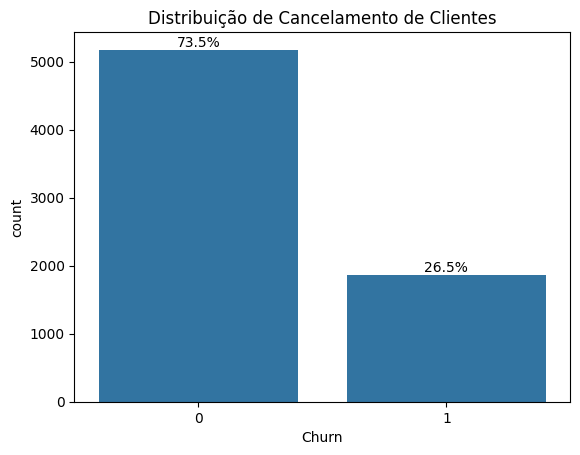

In [35]:
ax = sns.countplot(data=df, x='Churn')

total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Distribuição de Cancelamento de Clientes')
plt.show()

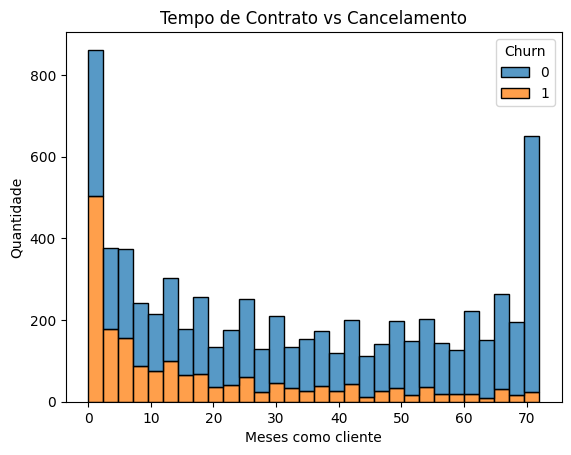

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.histplot(data=df, x='customer.tenure', hue='Churn', multiple='stack', bins=30)

plt.title('Tempo de Contrato vs Cancelamento')
plt.xlabel('Meses como cliente')
plt.ylabel('Quantidade')

plt.show()


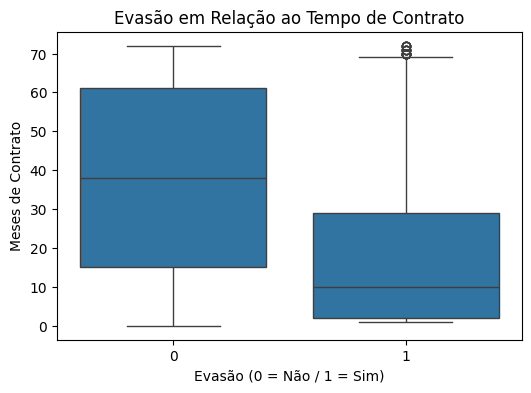

In [41]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x='Churn', y='customer.tenure')

plt.title('Evasão em Relação ao Tempo de Contrato')
plt.xlabel('Evasão (0 = Não / 1 = Sim)')
plt.ylabel('Meses de Contrato')

plt.show()

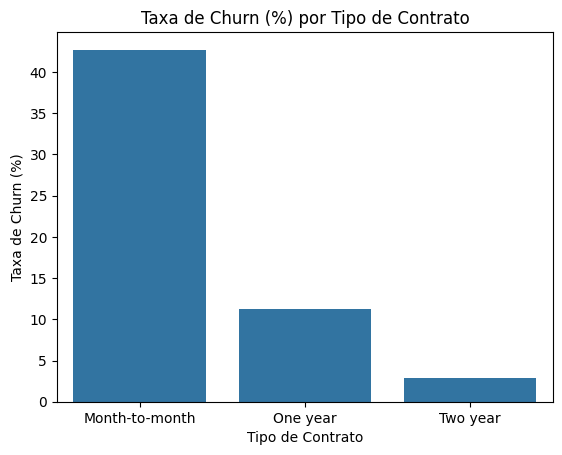

In [33]:
churn_contract = (
    df.groupby('account.Contract')['Churn']
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure()

sns.barplot(data=churn_contract, x='account.Contract', y='Churn')

plt.title('Taxa de Churn (%) por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Taxa de Churn (%)')

plt.show()

#6.2 Evasão por variáveis categóricas

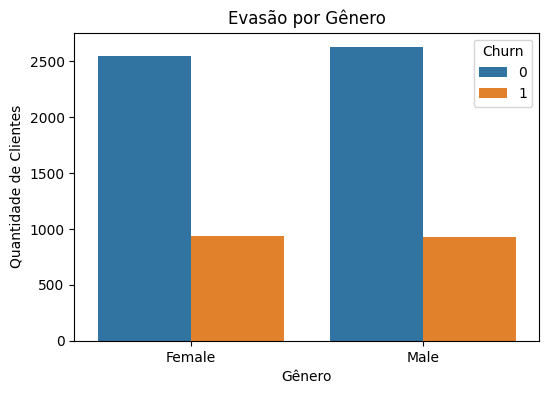

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='customer.gender', hue='Churn')

plt.title('Evasão por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Clientes')

plt.show()

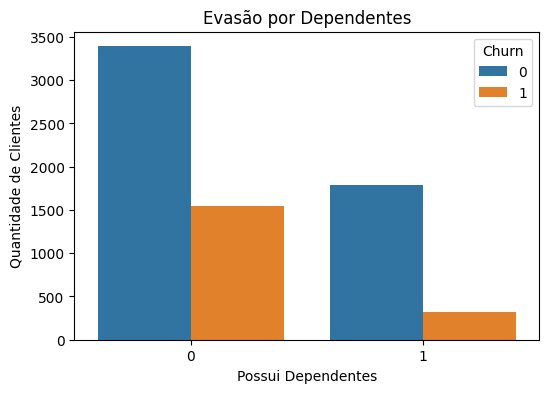

In [38]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='customer.Dependents', hue='Churn')

plt.title('Evasão por Dependentes')
plt.xlabel('Possui Dependentes')
plt.ylabel('Quantidade de Clientes')

plt.show()

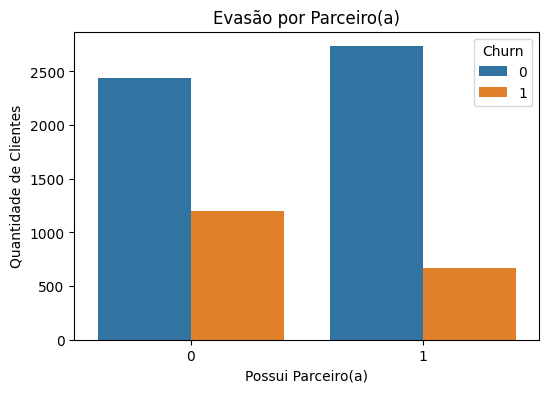

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='customer.Partner', hue='Churn')

plt.title('Evasão por Parceiro(a)')
plt.xlabel('Possui Parceiro(a)')
plt.ylabel('Quantidade de Clientes')

plt.show()

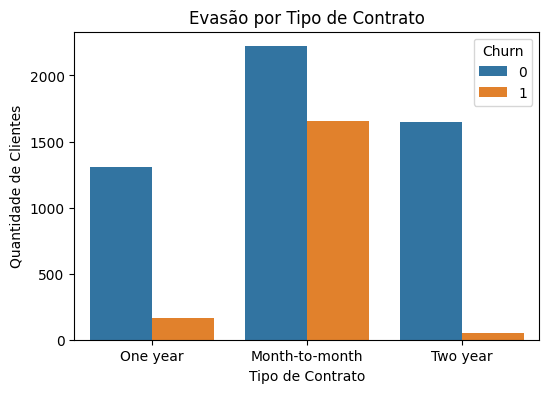

In [39]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='account.Contract', hue='Churn')

plt.title('Evasão por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')

plt.show()

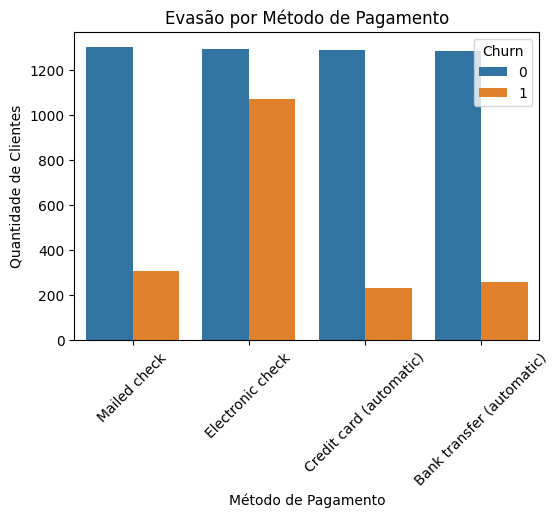

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='account.PaymentMethod', hue='Churn')

plt.title('Evasão por Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Quantidade de Clientes')

plt.xticks(rotation=45)

plt.show()

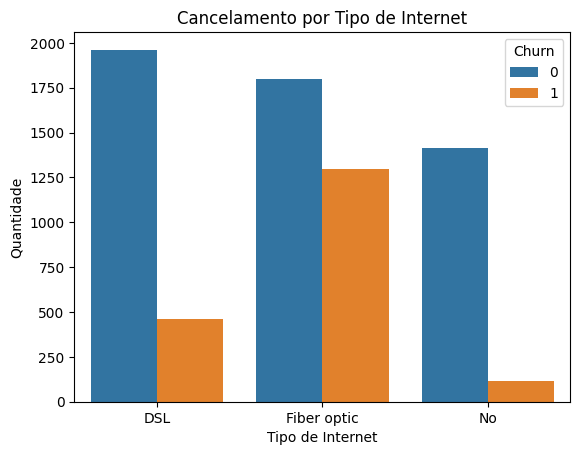

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.countplot(data=df, x='internet.InternetService', hue='Churn')

plt.title('Cancelamento por Tipo de Internet')
plt.xlabel('Tipo de Internet')
plt.ylabel('Quantidade')

plt.show()


#6.3 Evasão em relação a variáveis numéricas

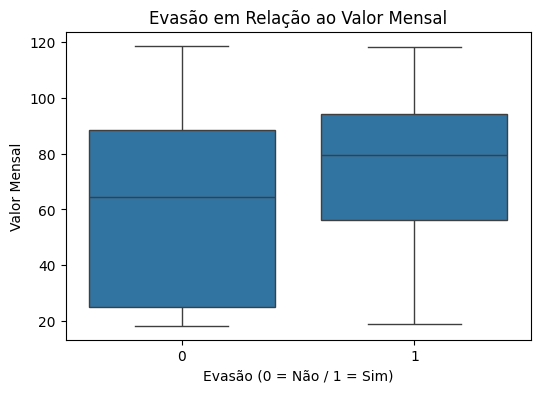

In [42]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

plt.title('Evasão em Relação ao Valor Mensal')
plt.xlabel('Evasão (0 = Não / 1 = Sim)')
plt.ylabel('Valor Mensal')

plt.show()

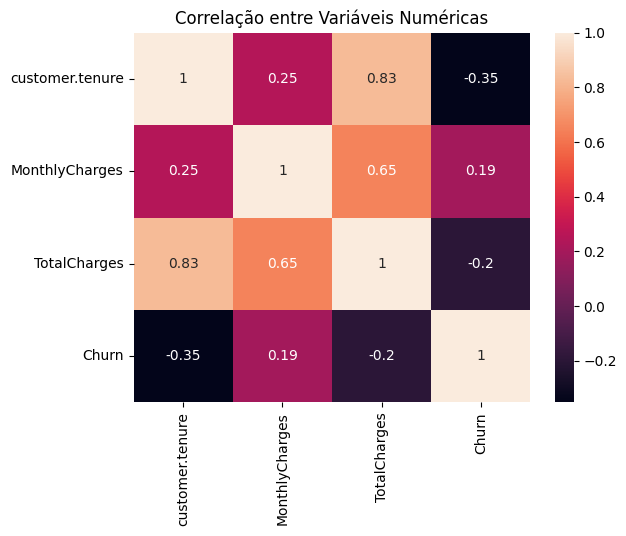

In [34]:
plt.figure()

correlacao = df[['customer.tenure','MonthlyCharges','TotalCharges','Churn']].corr()

sns.heatmap(correlacao, annot=True)

plt.title('Correlação entre Variáveis Numéricas')

plt.show()

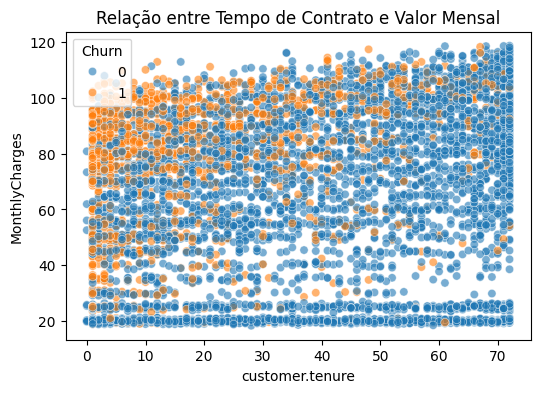

In [62]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x='customer.tenure',
    y='MonthlyCharges',
    hue='Churn',
    alpha=0.6
)

plt.title('Relação entre Tempo de Contrato e Valor Mensal')
plt.show()


#6.4 Evasão por serviços adicionais

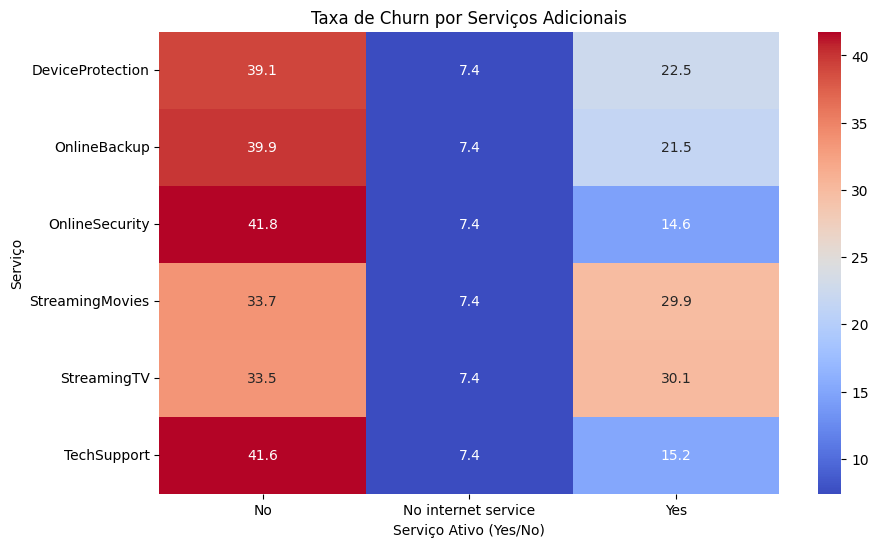

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# lista de serviços com prefixo correto
servicos = [
    'internet.OnlineSecurity',
    'internet.OnlineBackup',
    'internet.DeviceProtection',
    'internet.TechSupport',
    'internet.StreamingTV',
    'internet.StreamingMovies'
]

dados_heatmap = []

for servico in servicos:
    # calcular taxa de churn (1 = cancelou)
    taxa = (
        df.groupby(servico)['Churn']
        .mean()           # média = proporção de churn
        .mul(100)         # transforma em %
        .reset_index(name='percent')
    )

    taxa['Service'] = servico.replace('internet.', '')  # só o nome do serviço
    taxa['Status'] = taxa[servico]

    dados_heatmap.append(taxa)

# juntar todos os serviços
heatmap_df = pd.concat(dados_heatmap)

# pivotar para heatmap
pivot = heatmap_df.pivot(index='Service', columns='Status', values='percent')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap='coolwarm')

plt.title('Taxa de Churn por Serviços Adicionais')
plt.xlabel('Serviço Ativo (Yes/No)')
plt.ylabel('Serviço')
plt.show()

# 7. Insights

# 📊 Relatório Final — Análise de Evasão de Clientes (Churn)

---

# 🧭 1. Introdução

Este projeto tem como objetivo analisar os fatores que influenciam a **evasão de clientes (Churn)** na empresa **Telecom X**.

A evasão de clientes é um problema relevante para empresas de serviços por assinatura, pois impacta diretamente:

- 📉 Receita recorrente
- 💰 Custos de aquisição de novos clientes
- 📊 Crescimento sustentável do negócio

Utilizando dados demográficos, financeiros e de serviços contratados pelos clientes, foi realizada uma **Análise Exploratória de Dados (EDA)** para identificar padrões associados ao cancelamento de serviços.

🎯 **Objetivo da análise:**  
Identificar os fatores que aumentam a probabilidade de churn e gerar **insights estratégicos para retenção de clientes**.

---

# 🧹 2. Limpeza e Tratamento de Dados

Os dados foram carregados a partir de um **arquivo JSON** e convertidos para um **DataFrame utilizando a biblioteca Pandas**.

## 🔧 Etapas realizadas

- 🔍 Verificação da estrutura do dataset (`info()` e `describe()`)
- ⚠️ Identificação de **valores ausentes**
- 🧹 Remoção de **registros duplicados**
- 🔄 Padronização de variáveis categóricas
- 💲 Conversão das colunas financeiras para formato numérico:
  - `MonthlyCharges`
  - `TotalCharges`
- 🔢 Conversão da variável **Churn** para formato binário:
  - `0 → Cliente permaneceu`
  - `1 → Cliente cancelou`
- 🏷️ Padronização de nomes de colunas

✅ Após essas etapas, os dados estavam **consistentes e prontos para análise exploratória**.

---

# 🔎 3. Análise Exploratória de Dados (EDA)

---

# 📊 3.1 Distribuição Geral de Churn

A análise inicial mostra que:

- **73,5% dos clientes permanecem**
- **26,5% dos clientes cancelam o serviço**

📈 Isso indica que **aproximadamente 1 em cada 4 clientes abandona o serviço**, o que representa um impacto relevante na retenção.

💡 Esse nível de churn sugere a necessidade de **estratégias focadas em fidelização e melhoria da experiência do cliente**.

---

# 📄 3.2 Churn por Tipo de Contrato

O gráfico mostra uma **diferença muito significativa entre os tipos de contrato**.

| Tipo de contrato | Taxa de churn |
|---|---|
| Month-to-month | ~43% |
| One year | ~11% |
| Two year | ~3% |

📊 **Interpretação**

Clientes com **contratos mensais apresentam a maior taxa de evasão**, enquanto contratos mais longos apresentam maior retenção.

💡 Isso ocorre porque contratos longos criam **maior compromisso do cliente com o serviço**.

✅ **Insight estratégico**

➡ Incentivar **planos anuais ou bienais** pode reduzir significativamente o churn.

---

# 👥 3.3 Evasão por Características Demográficas

## Gênero

A análise mostra que **não há diferença significativa entre homens e mulheres** na taxa de cancelamento.

📊 Isso indica que **gênero não é um fator relevante para prever churn**.

---

## Dependentes

Clientes **sem dependentes apresentam maior taxa de churn**.

📊 Possível interpretação:

Clientes com dependentes podem ter **maior necessidade de estabilidade no serviço**, reduzindo a probabilidade de cancelamento.

---

## Parceiro(a)

Clientes **sem parceiro(a)** também apresentam **maior probabilidade de churn**.

💡 Isso sugere que clientes com estrutura familiar podem ter **maior permanência no serviço**.

---

# 💳 3.4 Evasão por Método de Pagamento

O gráfico mostra diferenças relevantes entre os métodos de pagamento.

📊 **Electronic Check apresenta a maior taxa de churn**.

Possíveis razões:

- maior fricção no pagamento
- menor fidelização
- ausência de pagamento automático

Por outro lado:

💳 **Pagamentos automáticos (cartão ou débito)** apresentam **menor taxa de churn**.

✅ **Insight estratégico**

➡ Incentivar **pagamentos automáticos** pode reduzir a evasão.

---

# 🌐 3.5 Churn por Tipo de Internet

A análise mostra que:

| Tipo de Internet | Tendência de churn |
|---|---|
| Fiber optic | Maior churn |
| DSL | Moderado |
| Sem internet | Menor churn |

📊 Clientes com **Fiber Optic apresentam maior taxa de cancelamento**.

Possíveis causas:

- preços mais altos
- expectativas maiores de qualidade
- maior concorrência no mercado

---

# ⏳ 3.6 Tempo de Contrato (Tenure)

O boxplot mostra que:

- Clientes que cancelam possuem **tempo de contrato muito menor**
- Clientes que permanecem possuem **tenure mais longo**

📊 O histograma também mostra que **a maioria dos cancelamentos ocorre nos primeiros meses**.

💡 Isso indica um problema na **fase inicial da jornada do cliente**.

✅ **Insight**

➡ Melhorar o **onboarding do cliente** pode reduzir churn.

---

# 💰 3.7 Valor Mensal (MonthlyCharges)

O boxplot mostra que clientes que cancelam possuem **valores mensais mais altos em média**.

📊 Interpretação:

Clientes com maior custo mensal podem perceber **menor custo-benefício**, aumentando a probabilidade de cancelamento.

---

# 🔥 3.8 Correlação entre Variáveis Numéricas

O heatmap mostra as principais correlações:

| Variável | Correlação com Churn |
|---|---|
| Tenure | -0.35 |
| MonthlyCharges | 0.19 |
| TotalCharges | -0.20 |

📊 Interpretação:

- **Tenure possui correlação negativa com churn**  
  → quanto maior o tempo de contrato, menor a evasão

- **MonthlyCharges possui correlação positiva**  
  → valores mensais mais altos aumentam a probabilidade de churn

- **TotalCharges é fortemente correlacionado com Tenure (0.83)**  
  → clientes antigos naturalmente pagam mais no total

---

# 🛡️ 3.9 Serviços Adicionais e Churn

O heatmap mostra que clientes **sem serviços adicionais apresentam taxas de churn muito maiores**.

Taxas aproximadas:

| Serviço | Churn sem serviço |
|---|---|
| OnlineSecurity | ~41% |
| TechSupport | ~41% |
| DeviceProtection | ~39% |

Já clientes que possuem esses serviços apresentam churn muito menor (aprox. **7–15%**).

📊 Interpretação:

Serviços adicionais **aumentam o valor percebido do produto**, incentivando a permanência.

---

# 💡 4. Principais Insights

## 📄 Insight 1 — Contratos mensais geram muito mais churn

Clientes **month-to-month têm cerca de 4x mais churn** que contratos anuais.

➡ Estratégia: incentivar contratos longos.

---

## ⏳ Insight 2 — O churn acontece principalmente nos primeiros meses

Clientes novos cancelam com mais frequência.

➡ Estratégia: melhorar onboarding e suporte inicial.

---

## 💳 Insight 3 — Métodos de pagamento influenciam a retenção

Pagamentos automáticos reduzem churn.

➡ Estratégia: incentivar débito automático.

---

## 💰 Insight 4 — Preços mais altos aumentam o risco de cancelamento

Clientes com mensalidade maior apresentam mais churn.

➡ Estratégia: revisar percepção de valor dos planos.

---

## 🛡️ Insight 5 — Serviços adicionais aumentam retenção

Clientes com suporte, segurança e proteção apresentam muito menos churn.

➡ Estratégia: criar **pacotes de serviços combinados**.

---

# 🚀 5. Recomendações Estratégicas

### 📄 Incentivar contratos de longo prazo

- descontos progressivos
- bônus de fidelidade

---

### 👶 Melhorar a experiência inicial do cliente

- onboarding estruturado
- acompanhamento nos primeiros meses

---

### 💳 Incentivar pagamento automático

- descontos
- benefícios exclusivos

---

### 🛡️ Promover pacotes de serviços adicionais

- bundles com segurança e suporte
- ofertas personalizadas

---

# 📌 6. Conclusão

A análise identificou fatores críticos relacionados ao churn na Telecom X:

- tipo de contrato
- tempo de relacionamento
- valor mensal do serviço
- serviços adicionais contratados
- método de pagamento

📊 Esses insights permitem desenvolver **estratégias de retenção baseadas em dados**, aumentando:

- 📈 retenção de clientes
- 💰 receita recorrente
- 😊 satisfação dos usuários

---

⭐ **Conclusão final**

A utilização de **análise exploratória de dados (EDA)** demonstrou ser fundamental para compreender o comportamento dos clientes e apoiar decisões estratégicas orientadas por dados (**data-driven decisions**).

